# 🏭 Supply Chain Performance Analysis
**Domain:** Beauty & Personal Care | **Tools:** Python, SQL, Power BI  
**Dataset:** 100 SKUs across 5 Indian cities  
**Author:** **Rushikesh Ramesh Sangamnere**

---
## 📌 Problem Statement
A Beauty & Personal Care company operates supply chain across 5 major Indian cities.
The goal is to analyze supplier performance, shipping efficiency, manufacturing quality,
and inventory health to identify bottlenecks and recommend data-driven improvements.

## 🎯 Objectives
1. Analyze **product-level revenue and defect** performance
2. Evaluate **supplier reliability** using lead time, defect rate, and cost
3. Compare **shipping carriers and transport modes** for efficiency
4. Identify **quality inspection failures** and their business impact
5. Build a **Supplier Risk Scorecard** for decision-making
6. Provide **actionable business recommendations**

---
## 📦 Section 1: Setup & Data Loading

In [39]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os                       
warnings.filterwarnings('ignore')

# ── Plot Styling ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11
})
COLORS = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

# ── Create folders if not exist ───────────────────────────────────────────
os.makedirs('dashboard', exist_ok=True)  
os.makedirs('data', exist_ok=True)       

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [40]:
# ── Load Dataset ──────────────────────────────────────────────────────────
df = pd.read_csv('supply_chain_data.csv')

print(f'📊 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'📋 Columns: {df.columns.tolist()}')
df.head()

📊 Dataset Shape: 100 rows × 24 columns
📋 Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


---
## 🔍 Section 2: Data Understanding & Quality Check

In [41]:
# ── Data Types & Null Check ───────────────────────────────────────────────
print('='*50)
print('DATA TYPES')
print('='*50)
print(df.dtypes)

print('\n' + '='*50)
print('NULL VALUE CHECK')
print('='*50)
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '✅ No null values found — dataset is clean!')

print('\n' + '='*50)
print('DUPLICATE CHECK')
print('='*50)
dupes = df.duplicated().sum()
print(f'✅ Duplicate rows: {dupes}')

DATA TYPES
Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time                    int64
Production volumes           int64
Manufacturing lead time      int64
Manufacturing costs        float64
Inspection results          object
Defect rates               float64
Transportation modes        object
Routes                      object
Costs                      float64
dtype: object

NULL VALUE CHECK
✅ No null values found — dataset is clean!

DUPLICATE CHECK
✅ Duplicate rows: 0


In [42]:
# ── Statistical Summary ───────────────────────────────────────────────────
print('NUMERICAL COLUMNS — STATISTICAL SUMMARY')
df.describe().round(2)

NUMERICAL COLUMNS — STATISTICAL SUMMARY


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
mean,49.46,48.40,460.99,5776.05,47.77,15.96,49.22,5.75,5.55,17.08,567.84,14.77,47.27,2.28,529.25
std,31.17,30.74,303.78,2732.84,31.37,8.79,26.78,2.72,2.65,8.85,263.05,8.91,28.98,1.46,258.30
min,1.70,1.00,8.00,1061.62,0.00,1.00,1.00,1.00,1.01,1.00,104.00,1.00,1.09,0.02,103.92
25%,19.60,22.75,184.25,2812.85,16.75,8.00,26.00,3.75,3.54,10.00,352.00,7.00,22.98,1.01,318.78
50%,51.24,43.50,392.50,6006.35,47.50,17.00,52.00,6.00,5.32,18.00,568.50,14.00,45.91,2.14,520.43
75%,77.20,75.00,704.25,8253.98,73.00,24.00,71.25,8.00,7.60,25.00,797.00,23.00,68.62,3.56,763.08
max,99.17,100.00,996.00,9866.47,100.00,30.00,96.00,10.00,9.93,30.00,985.00,30.00,99.47,4.94,997.41


In [43]:
# ── Categorical Columns Distribution ─────────────────────────────────────
cat_cols = ['Product type','Supplier name','Location','Shipping carriers',
            'Transportation modes','Inspection results','Routes']

for col in cat_cols:
    print(f'{col}: {dict(df[col].value_counts())}')

Product type: {'skincare': np.int64(40), 'haircare': np.int64(34), 'cosmetics': np.int64(26)}
Supplier name: {'Supplier 1': np.int64(27), 'Supplier 2': np.int64(22), 'Supplier 5': np.int64(18), 'Supplier 4': np.int64(18), 'Supplier 3': np.int64(15)}
Location: {'Kolkata': np.int64(25), 'Mumbai': np.int64(22), 'Chennai': np.int64(20), 'Bangalore': np.int64(18), 'Delhi': np.int64(15)}
Shipping carriers: {'Carrier B': np.int64(43), 'Carrier C': np.int64(29), 'Carrier A': np.int64(28)}
Transportation modes: {'Road': np.int64(29), 'Rail': np.int64(28), 'Air': np.int64(26), 'Sea': np.int64(17)}
Inspection results: {'Pending': np.int64(41), 'Fail': np.int64(36), 'Pass': np.int64(23)}
Routes: {'Route A': np.int64(43), 'Route B': np.int64(37), 'Route C': np.int64(20)}


In [44]:
# ── Data Cleaning: Standardize Column Names ───────────────────────────────
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
print('✅ Column names standardized:')
print(df.columns.tolist())

✅ Column names standardized:
['product_type', 'sku', 'price', 'availability', 'number_of_products_sold', 'revenue_generated', 'customer_demographics', 'stock_levels', 'lead_times', 'order_quantities', 'shipping_times', 'shipping_carriers', 'shipping_costs', 'supplier_name', 'location', 'lead_time', 'production_volumes', 'manufacturing_lead_time', 'manufacturing_costs', 'inspection_results', 'defect_rates', 'transportation_modes', 'routes', 'costs']


---
## 📊 Section 3: Product Performance Analysis

In [45]:
# ── Revenue & Sales by Product Type ──────────────────────────────────────
product_perf = df.groupby('product_type').agg(
    Total_Revenue    = ('revenue_generated', 'sum'),
    Avg_Price        = ('price', 'mean'),
    Total_Units_Sold = ('number_of_products_sold', 'sum'),
    Avg_Stock_Level  = ('stock_levels', 'mean'),
    Avg_Defect_Rate  = ('defect_rates', 'mean')
).round(2).reset_index()

product_perf['Revenue_Share_%'] = (
    product_perf['Total_Revenue'] / product_perf['Total_Revenue'].sum() * 100
).round(1)

print('PRODUCT PERFORMANCE SUMMARY')
print('='*70)
print(product_perf.to_string(index=False))

PRODUCT PERFORMANCE SUMMARY
product_type  Total_Revenue  Avg_Price  Total_Units_Sold  Avg_Stock_Level  Avg_Defect_Rate  Revenue_Share_%
   cosmetics      161521.27      57.36             11757            58.65             1.92             28.0
    haircare      174455.39      46.01             13611            48.35             2.48             30.2
    skincare      241628.16      47.26             20731            40.20             2.33             41.8


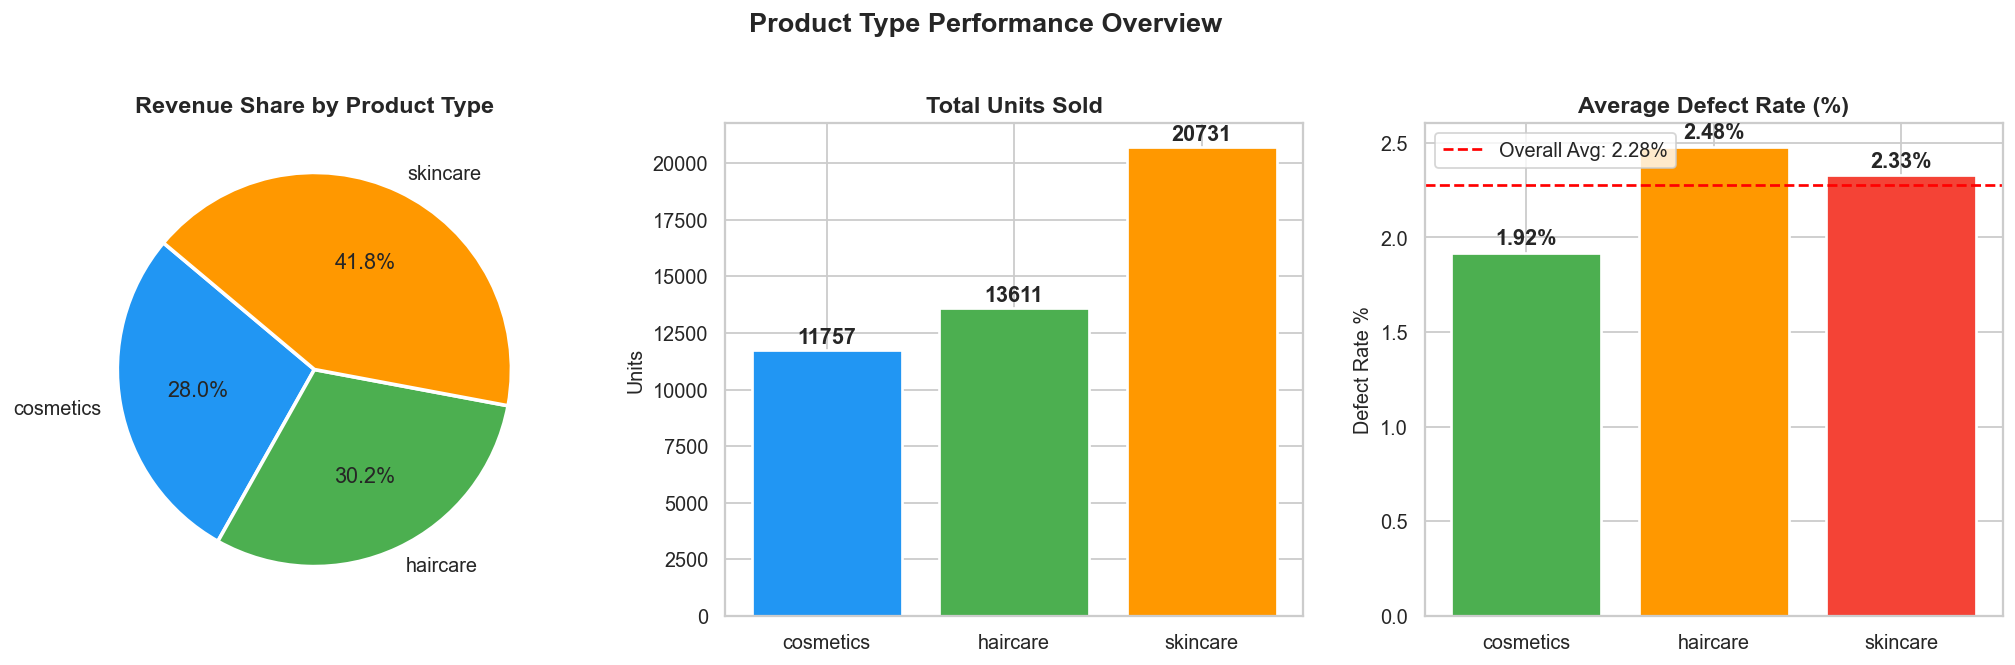


💡 KEY INSIGHT: Skincare leads in revenue (41.7%) and units sold (20,731)
💡 KEY INSIGHT: Haircare has highest defect rate (2.48%) — quality attention needed


In [46]:
# ── Visualization: Revenue & Units Sold by Product Type ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Product Type Performance Overview', fontsize=15, fontweight='bold', y=1.02)

# Plot 1 — Revenue Share Pie Chart
axes[0].pie(
    product_perf['Total_Revenue'],
    labels=product_perf['product_type'],
    autopct='%1.1f%%',
    colors=COLORS[:3],
    startangle=140,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)
axes[0].set_title('Revenue Share by Product Type')

# Plot 2 — Units Sold Bar Chart
bars = axes[1].bar(
    product_perf['product_type'],
    product_perf['Total_Units_Sold'],
    color=COLORS[:3],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, product_perf['Total_Units_Sold']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Total Units Sold')
axes[1].set_ylabel('Units')

# Plot 3 — Avg Defect Rate
bars2 = axes[2].bar(
    product_perf['product_type'],
    product_perf['Avg_Defect_Rate'],
    color=['#4CAF50','#FF9800','#F44336'],
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars2, product_perf['Avg_Defect_Rate']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
axes[2].set_title('Average Defect Rate (%)')
axes[2].set_ylabel('Defect Rate %')
axes[2].axhline(df['defect_rates'].mean(), color='red', linestyle='--',
                label=f'Overall Avg: {df["defect_rates"].mean():.2f}%')
axes[2].legend()

plt.tight_layout()
plt.savefig('dashboard/product_performance.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n💡 KEY INSIGHT: Skincare leads in revenue (41.7%) and units sold (20,731)')
print('💡 KEY INSIGHT: Haircare has highest defect rate (2.48%) — quality attention needed')

---
## 🏭 Section 4: Supplier Performance Analysis

In [47]:
# ── Supplier KPI Summary ──────────────────────────────────────────────────
supplier_perf = df.groupby('supplier_name').agg(
    Total_Revenue       = ('revenue_generated', 'sum'),
    Avg_Lead_Time       = ('lead_time', 'mean'),
    Avg_Defect_Rate     = ('defect_rates', 'mean'),
    Avg_Mfg_Cost        = ('manufacturing_costs', 'mean'),
    Total_Production    = ('production_volumes', 'sum'),
    Avg_Mfg_Lead_Time   = ('manufacturing_lead_time', 'mean'),
    Total_SKUs          = ('sku', 'count')
).round(2).reset_index()

print('SUPPLIER PERFORMANCE KPIs')
print('='*80)
print(supplier_perf.to_string(index=False))

SUPPLIER PERFORMANCE KPIs
supplier_name  Total_Revenue  Avg_Lead_Time  Avg_Defect_Rate  Avg_Mfg_Cost  Total_Production  Avg_Mfg_Lead_Time  Total_SKUs
   Supplier 1      157529.00          14.78             1.80         45.25             13545              12.59          27
   Supplier 2      125467.42          18.55             2.36         41.62             14105              15.59          22
   Supplier 3       97795.98          20.13             2.47         43.63              7997              14.93          15
   Supplier 4       86468.96          15.22             2.34         62.71             11756              15.33          18
   Supplier 5      110343.46          18.06             2.67         44.77              9381              16.33          18


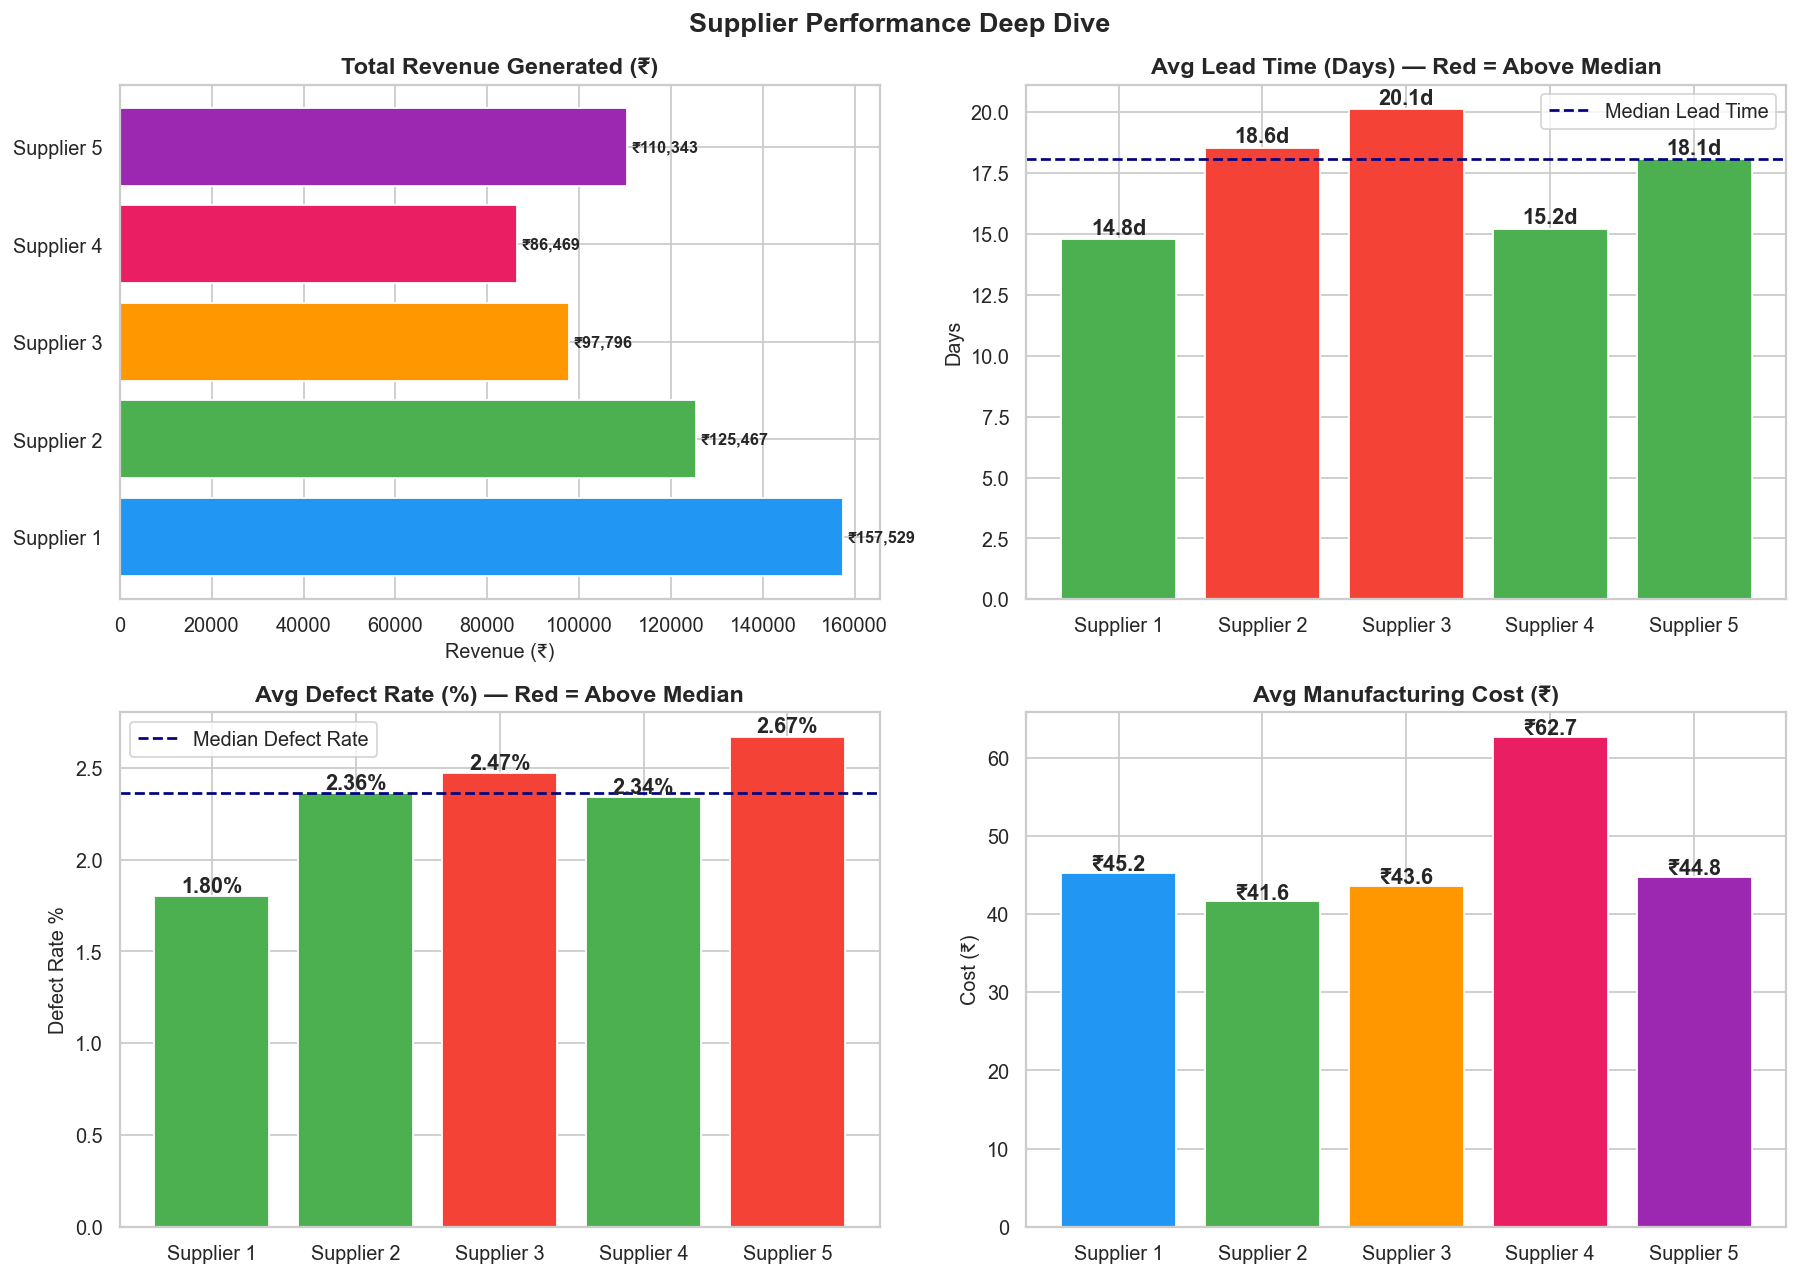


💡 KEY INSIGHT: Supplier 1 generates highest revenue (₹1,57,529) with lowest defect rate (1.80%)
💡 KEY INSIGHT: Supplier 3 has highest lead time (20.1 days) — delivery bottleneck
💡 KEY INSIGHT: Supplier 4 has highest manufacturing cost (₹62.71) — cost optimization needed


In [48]:
# ── Visualization: Supplier Comparison ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Supplier Performance Deep Dive', fontsize=15, fontweight='bold')

suppliers = supplier_perf['supplier_name']

# Plot 1 — Total Revenue by Supplier
bars = axes[0,0].barh(suppliers, supplier_perf['Total_Revenue'],
                       color=COLORS, edgecolor='white')
for bar, val in zip(bars, supplier_perf['Total_Revenue']):
    axes[0,0].text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
                    f'₹{val:,.0f}', va='center', fontsize=9, fontweight='bold')
axes[0,0].set_title('Total Revenue Generated (₹)')
axes[0,0].set_xlabel('Revenue (₹)')

# Plot 2 — Avg Lead Time
bar_colors = ['#4CAF50' if v <= supplier_perf['Avg_Lead_Time'].median()
               else '#F44336' for v in supplier_perf['Avg_Lead_Time']]
bars2 = axes[0,1].bar(suppliers, supplier_perf['Avg_Lead_Time'],
                       color=bar_colors, edgecolor='white')
for bar, val in zip(bars2, supplier_perf['Avg_Lead_Time']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val:.1f}d', ha='center', fontweight='bold')
axes[0,1].axhline(supplier_perf['Avg_Lead_Time'].median(), color='navy',
                   linestyle='--', label='Median Lead Time')
axes[0,1].set_title('Avg Lead Time (Days) — Red = Above Median')
axes[0,1].set_ylabel('Days')
axes[0,1].legend()

# Plot 3 — Avg Defect Rate
bar_colors3 = ['#F44336' if v > supplier_perf['Avg_Defect_Rate'].median()
                else '#4CAF50' for v in supplier_perf['Avg_Defect_Rate']]
bars3 = axes[1,0].bar(suppliers, supplier_perf['Avg_Defect_Rate'],
                       color=bar_colors3, edgecolor='white')
for bar, val in zip(bars3, supplier_perf['Avg_Defect_Rate']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.2f}%', ha='center', fontweight='bold')
axes[1,0].axhline(supplier_perf['Avg_Defect_Rate'].median(), color='navy',
                   linestyle='--', label='Median Defect Rate')
axes[1,0].set_title('Avg Defect Rate (%) — Red = Above Median')
axes[1,0].set_ylabel('Defect Rate %')
axes[1,0].legend()

# Plot 4 — Manufacturing Cost
bars4 = axes[1,1].bar(suppliers, supplier_perf['Avg_Mfg_Cost'],
                       color=COLORS, edgecolor='white')
for bar, val in zip(bars4, supplier_perf['Avg_Mfg_Cost']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    f'₹{val:.1f}', ha='center', fontweight='bold')
axes[1,1].set_title('Avg Manufacturing Cost (₹)')
axes[1,1].set_ylabel('Cost (₹)')

plt.tight_layout()
plt.savefig('dashboard/supplier_performance.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n💡 KEY INSIGHT: Supplier 1 generates highest revenue (₹1,57,529) with lowest defect rate (1.80%)')
print('💡 KEY INSIGHT: Supplier 3 has highest lead time (20.1 days) — delivery bottleneck')
print('💡 KEY INSIGHT: Supplier 4 has highest manufacturing cost (₹62.71) — cost optimization needed')

---
## 🚚 Section 5: Shipping & Transportation Analysis

In [49]:
# ── Carrier Performance ───────────────────────────────────────────────────
carrier_perf = df.groupby('shipping_carriers').agg(
    Avg_Shipping_Cost = ('shipping_costs', 'mean'),
    Avg_Shipping_Time = ('shipping_times', 'mean'),
    Total_Orders      = ('sku', 'count'),
    Total_Revenue     = ('revenue_generated', 'sum')
).round(2).reset_index()

print('CARRIER PERFORMANCE')
print(carrier_perf.to_string(index=False))

# ── Transport Mode Performance ────────────────────────────────────────────
transport_perf = df.groupby('transportation_modes').agg(
    Avg_Total_Cost    = ('costs', 'mean'),
    Avg_Shipping_Time = ('shipping_times', 'mean'),
    Total_Orders      = ('sku', 'count'),
    Avg_Shipping_Cost = ('shipping_costs', 'mean')
).round(2).reset_index()

print('\nTRANSPORT MODE PERFORMANCE')
print(transport_perf.to_string(index=False))

CARRIER PERFORMANCE
shipping_carriers  Avg_Shipping_Cost  Avg_Shipping_Time  Total_Orders  Total_Revenue
        Carrier A               5.55               6.14            28      142629.99
        Carrier B               5.51               5.30            43      250094.65
        Carrier C               5.60               6.03            29      184880.18

TRANSPORT MODE PERFORMANCE
transportation_modes  Avg_Total_Cost  Avg_Shipping_Time  Total_Orders  Avg_Shipping_Cost
                 Air          561.71               5.12            26               6.02
                Rail          541.75               6.57            28               5.47
                Road          553.39               4.72            29               5.54
                 Sea          417.82               7.12            17               4.97


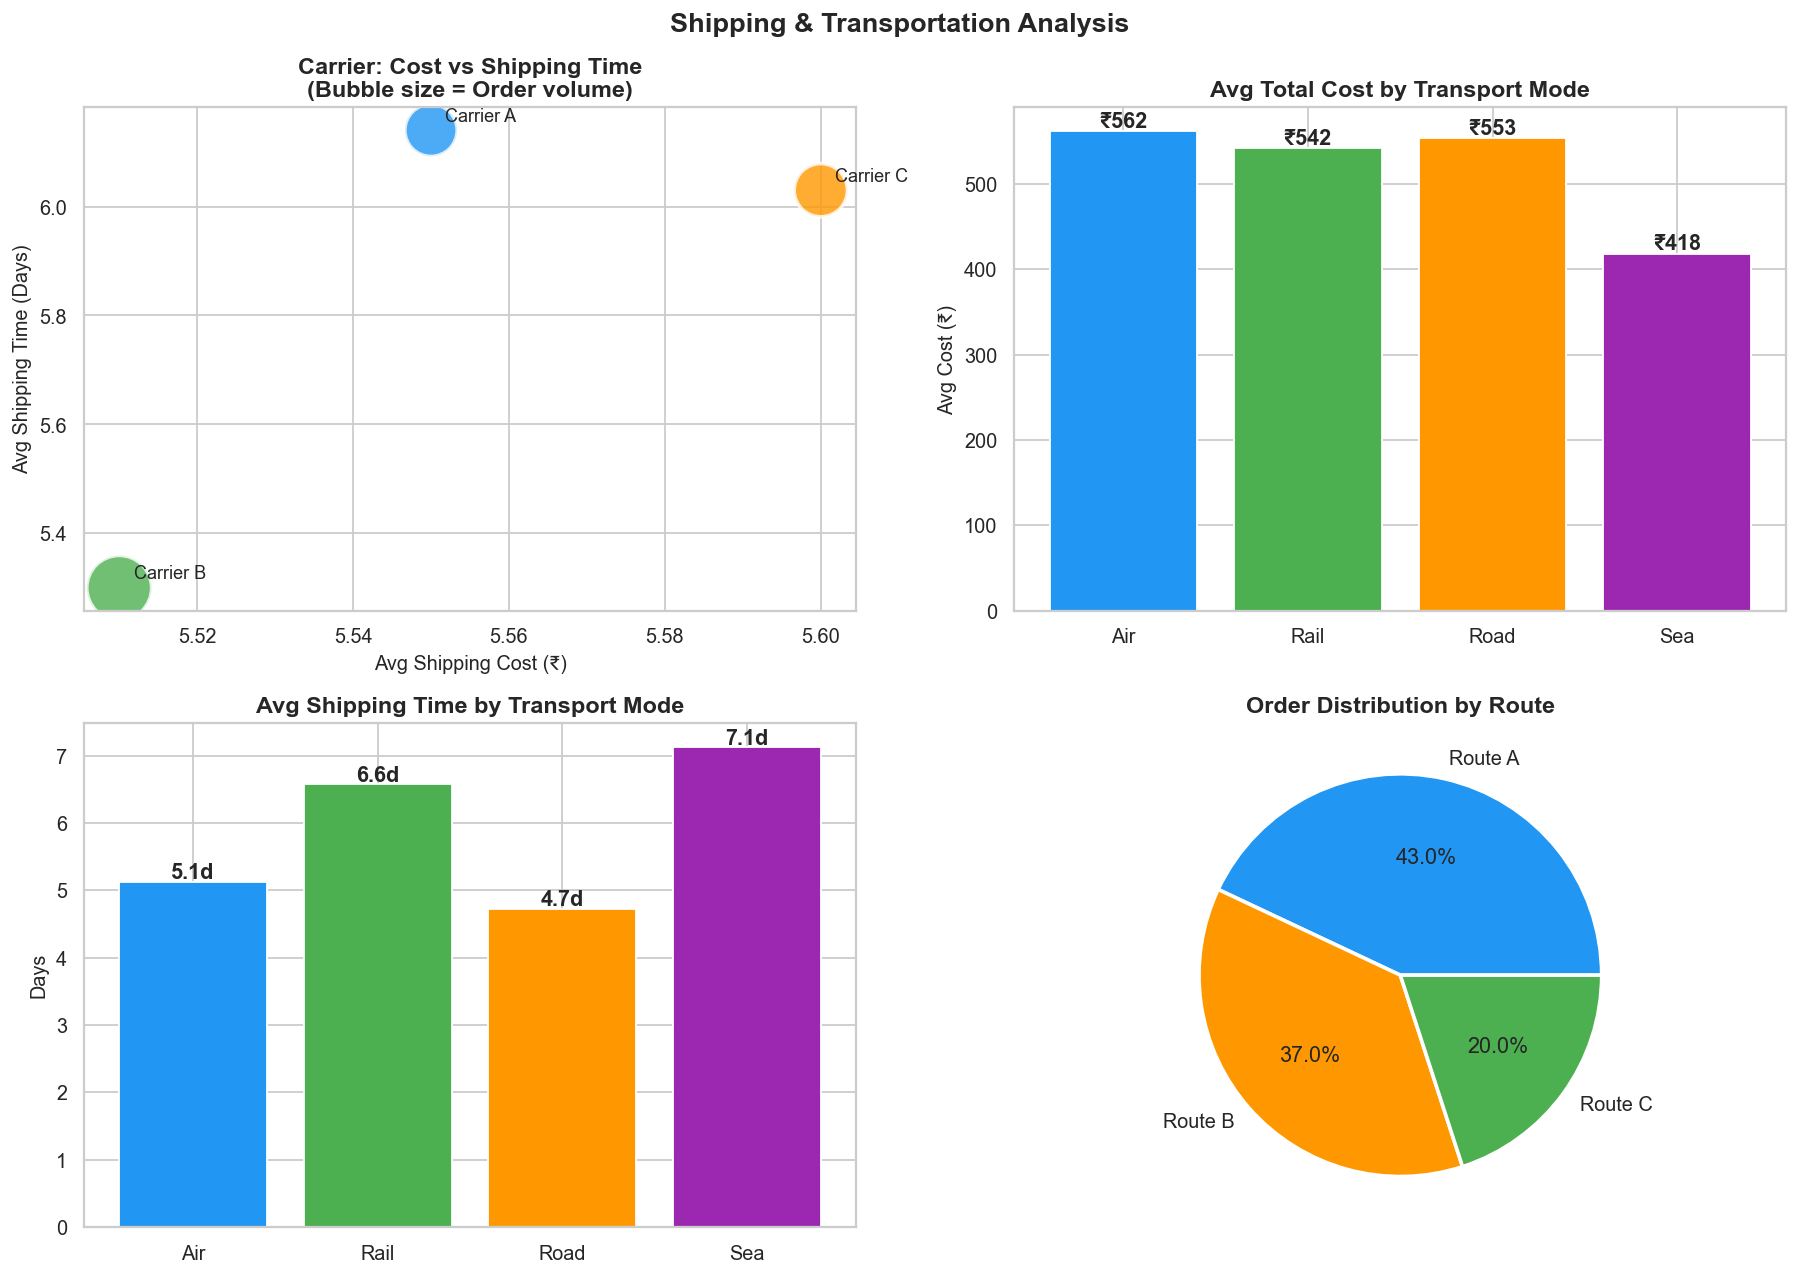


💡 KEY INSIGHT: Sea transport is cheapest (₹417) but slowest (7.1 days)
💡 KEY INSIGHT: Road is fastest (4.7 days) at mid-range cost — ideal for urgent orders
💡 KEY INSIGHT: Carrier B handles most orders (43%) with lowest avg shipping time (5.3 days)


In [50]:
# ── Visualization: Shipping Analysis ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Shipping & Transportation Analysis', fontsize=15, fontweight='bold')

# Plot 1 — Carrier: Cost vs Time
scatter = axes[0,0].scatter(
    carrier_perf['Avg_Shipping_Cost'],
    carrier_perf['Avg_Shipping_Time'],
    s=carrier_perf['Total_Orders'] * 30,
    c=COLORS[:3], alpha=0.8, edgecolors='white', linewidth=2
)
for _, row in carrier_perf.iterrows():
    axes[0,0].annotate(row['shipping_carriers'],
                        (row['Avg_Shipping_Cost'], row['Avg_Shipping_Time']),
                        textcoords='offset points', xytext=(8, 5), fontsize=10)
axes[0,0].set_title('Carrier: Cost vs Shipping Time\n(Bubble size = Order volume)')
axes[0,0].set_xlabel('Avg Shipping Cost (₹)')
axes[0,0].set_ylabel('Avg Shipping Time (Days)')

# Plot 2 — Transport Mode: Avg Total Cost
mode_colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
bars = axes[0,1].bar(transport_perf['transportation_modes'],
                      transport_perf['Avg_Total_Cost'],
                      color=mode_colors, edgecolor='white')
for bar, val in zip(bars, transport_perf['Avg_Total_Cost']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f'₹{val:.0f}', ha='center', fontweight='bold')
axes[0,1].set_title('Avg Total Cost by Transport Mode')
axes[0,1].set_ylabel('Avg Cost (₹)')

# Plot 3 — Transport Mode: Shipping Time
bars3 = axes[1,0].bar(transport_perf['transportation_modes'],
                       transport_perf['Avg_Shipping_Time'],
                       color=mode_colors, edgecolor='white')
for bar, val in zip(bars3, transport_perf['Avg_Shipping_Time']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.1f}d', ha='center', fontweight='bold')
axes[1,0].set_title('Avg Shipping Time by Transport Mode')
axes[1,0].set_ylabel('Days')

# Plot 4 — Route Distribution
route_dist = df['routes'].value_counts()
axes[1,1].pie(route_dist.values, labels=route_dist.index,
               autopct='%1.1f%%', colors=['#2196F3','#FF9800','#4CAF50'],
               wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,1].set_title('Order Distribution by Route')

plt.tight_layout()
plt.savefig('dashboard/shipping_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n💡 KEY INSIGHT: Sea transport is cheapest (₹417) but slowest (7.1 days)')
print('💡 KEY INSIGHT: Road is fastest (4.7 days) at mid-range cost — ideal for urgent orders')
print('💡 KEY INSIGHT: Carrier B handles most orders (43%) with lowest avg shipping time (5.3 days)')

---
## 🔬 Section 6: Quality Inspection Analysis

In [51]:
# ── Inspection Results Overview ───────────────────────────────────────────
inspection = df['inspection_results'].value_counts().reset_index()
inspection.columns = ['Result', 'Count']
inspection['Percentage'] = (inspection['Count'] / len(df) * 100).round(1)

print('QUALITY INSPECTION RESULTS')
print('='*40)
print(inspection.to_string(index=False))

total_fail = inspection[inspection['Result']=='Fail']['Count'].values[0]
total_pending = inspection[inspection['Result']=='Pending']['Count'].values[0]
print(f'\n⚠️  CRITICAL: {total_fail} SKUs ({total_fail}%) FAILED inspection')
print(f'⚠️  CRITICAL: {total_pending} SKUs ({total_pending}%) still PENDING — not yet cleared')

QUALITY INSPECTION RESULTS
 Result  Count  Percentage
Pending     41        41.0
   Fail     36        36.0
   Pass     23        23.0

⚠️  CRITICAL: 36 SKUs (36%) FAILED inspection
⚠️  CRITICAL: 41 SKUs (41%) still PENDING — not yet cleared


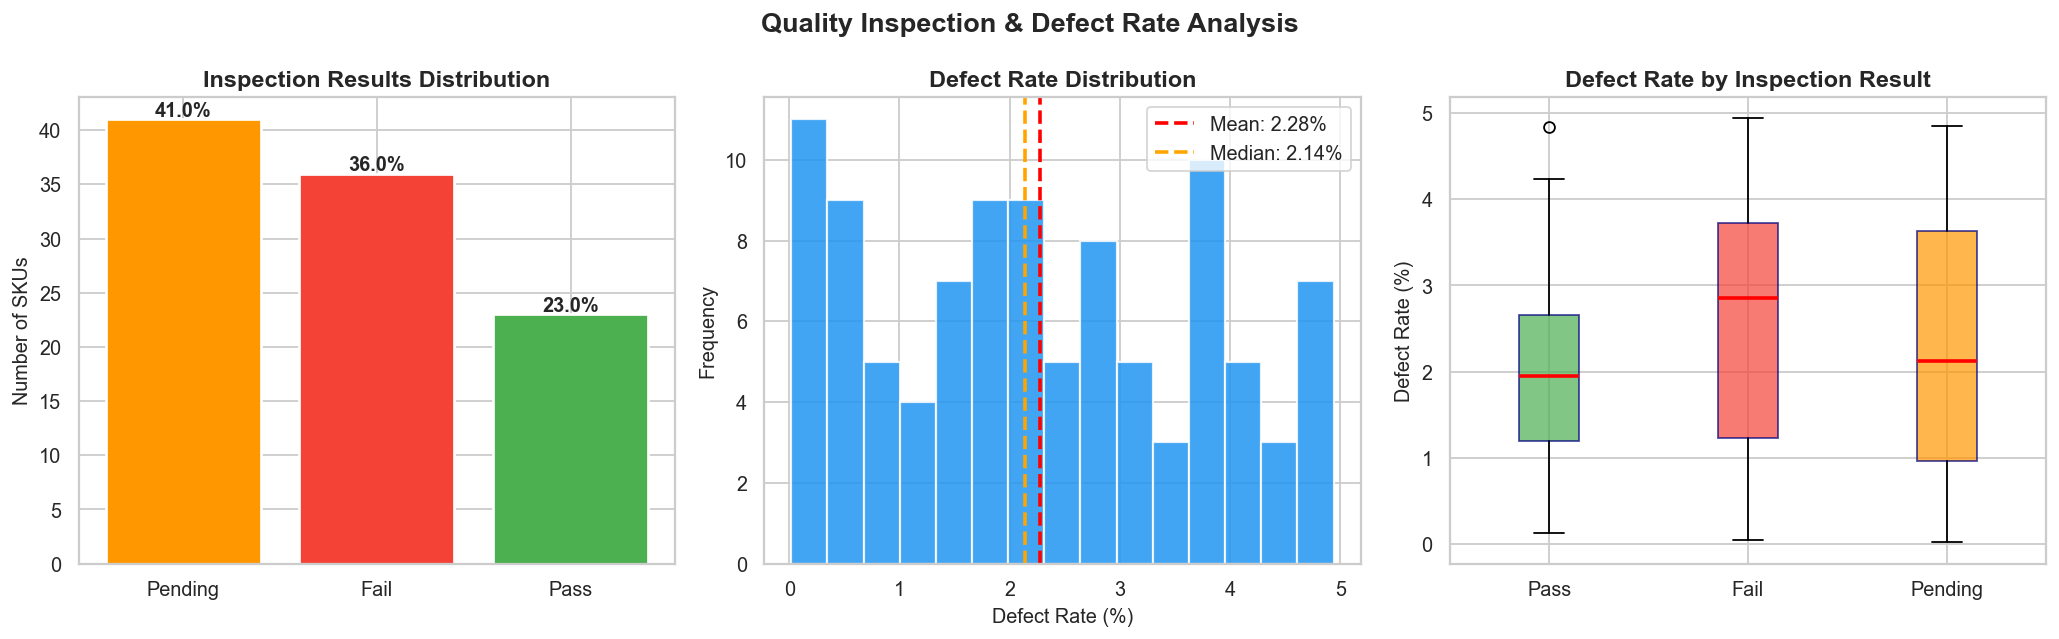


💡 KEY INSIGHT: 36% SKUs failed inspection — significant quality control gap
💡 KEY INSIGHT: 41% SKUs pending — large backlog affecting supply chain flow


In [52]:
# ── Defect Rate Deep Analysis ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Quality Inspection & Defect Rate Analysis', fontsize=15, fontweight='bold')

# Plot 1 — Inspection Results Distribution
colors_insp = {'Pass':'#4CAF50','Fail':'#F44336','Pending':'#FF9800'}
bar_colors = [colors_insp[r] for r in inspection['Result']]
bars = axes[0].bar(inspection['Result'], inspection['Count'],
                    color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, inspection['Percentage']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{pct}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Inspection Results Distribution')
axes[0].set_ylabel('Number of SKUs')

# Plot 2 — Defect Rate Distribution (Histogram)
axes[1].hist(df['defect_rates'], bins=15, color='#2196F3',
              edgecolor='white', linewidth=1.2, alpha=0.85)
axes[1].axvline(df['defect_rates'].mean(), color='red', linestyle='--',
                 linewidth=2, label=f"Mean: {df['defect_rates'].mean():.2f}%")
axes[1].axvline(df['defect_rates'].median(), color='orange', linestyle='--',
                 linewidth=2, label=f"Median: {df['defect_rates'].median():.2f}%")
axes[1].set_title('Defect Rate Distribution')
axes[1].set_xlabel('Defect Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Plot 3 — Defect Rate by Inspection Result (Boxplot)
pass_data = df[df['inspection_results']=='Pass']['defect_rates']
fail_data = df[df['inspection_results']=='Fail']['defect_rates']
pend_data = df[df['inspection_results']=='Pending']['defect_rates']

bp = axes[2].boxplot([pass_data, fail_data, pend_data],
                      labels=['Pass','Fail','Pending'],
                      patch_artist=True,
                      boxprops=dict(facecolor='lightblue', color='navy'),
                      medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], ['#4CAF50','#F44336','#FF9800']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Defect Rate by Inspection Result')
axes[2].set_ylabel('Defect Rate (%)')

plt.tight_layout()
plt.savefig('dashboard/quality_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n💡 KEY INSIGHT: 36% SKUs failed inspection — significant quality control gap")
print(f"💡 KEY INSIGHT: 41% SKUs pending — large backlog affecting supply chain flow")

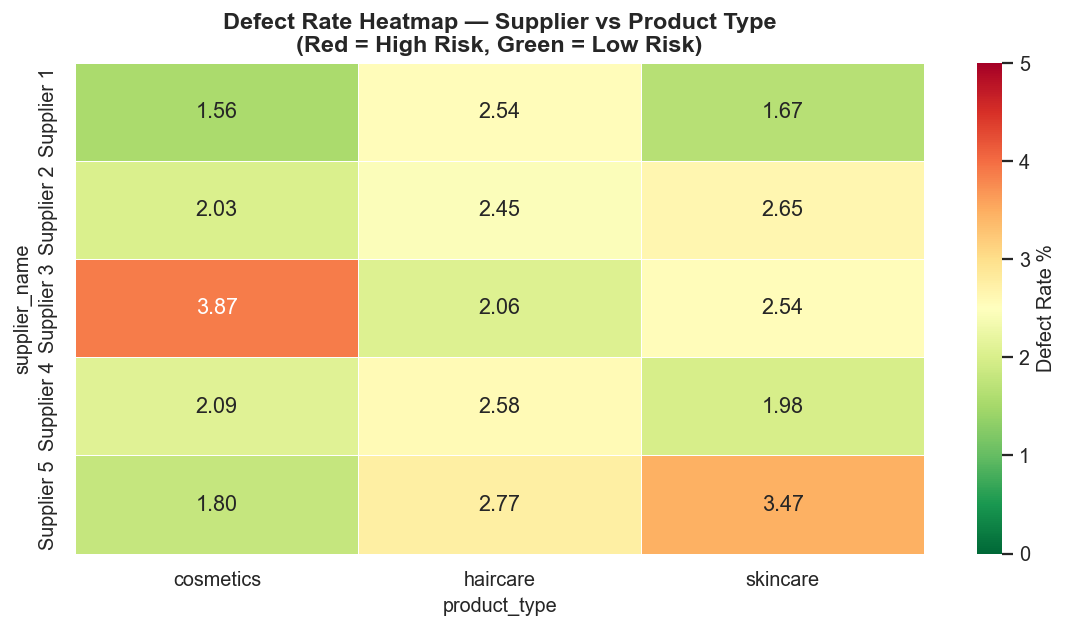


💡 KEY INSIGHT: Use this heatmap to identify which Supplier-Product combos need quality audits


In [53]:
# ── Defect Rate by Supplier x Product Type (Heatmap) ─────────────────────
pivot_defect = df.pivot_table(
    values='defect_rates',
    index='supplier_name',
    columns='product_type',
    aggfunc='mean'
).round(2)

plt.figure(figsize=(9, 5))
sns.heatmap(
    pivot_defect,
    annot=True, fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.5,
    cbar_kws={'label': 'Defect Rate %'},
    vmin=0, vmax=5
)
plt.title('Defect Rate Heatmap — Supplier vs Product Type\n(Red = High Risk, Green = Low Risk)',
           fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/defect_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n💡 KEY INSIGHT: Use this heatmap to identify which Supplier-Product combos need quality audits')

---
## 📦 Section 7: Inventory & Location Analysis

In [54]:
# ── Location-wise Performance ─────────────────────────────────────────────
location_perf = df.groupby('location').agg(
    Total_Revenue       = ('revenue_generated', 'sum'),
    Avg_Defect_Rate     = ('defect_rates', 'mean'),
    Total_Orders        = ('sku', 'count'),
    Avg_Stock_Level     = ('stock_levels', 'mean'),
    Avg_Lead_Time       = ('lead_time', 'mean'),
    Avg_Shipping_Cost   = ('shipping_costs', 'mean')
).round(2).reset_index()

print('LOCATION-WISE PERFORMANCE')
print(location_perf.to_string(index=False))

LOCATION-WISE PERFORMANCE
 location  Total_Revenue  Avg_Defect_Rate  Total_Orders  Avg_Stock_Level  Avg_Lead_Time  Avg_Shipping_Cost
Bangalore      102601.72             2.09            18            47.56          16.28               5.75
  Chennai      119142.82             2.64            20            39.95          18.65               4.69
    Delhi       81027.70             2.23            15            50.07          14.60               5.07
  Kolkata      137077.55             2.29            25            57.56          19.44               5.76
   Mumbai      137755.03             2.12            22            42.36          15.32               6.25


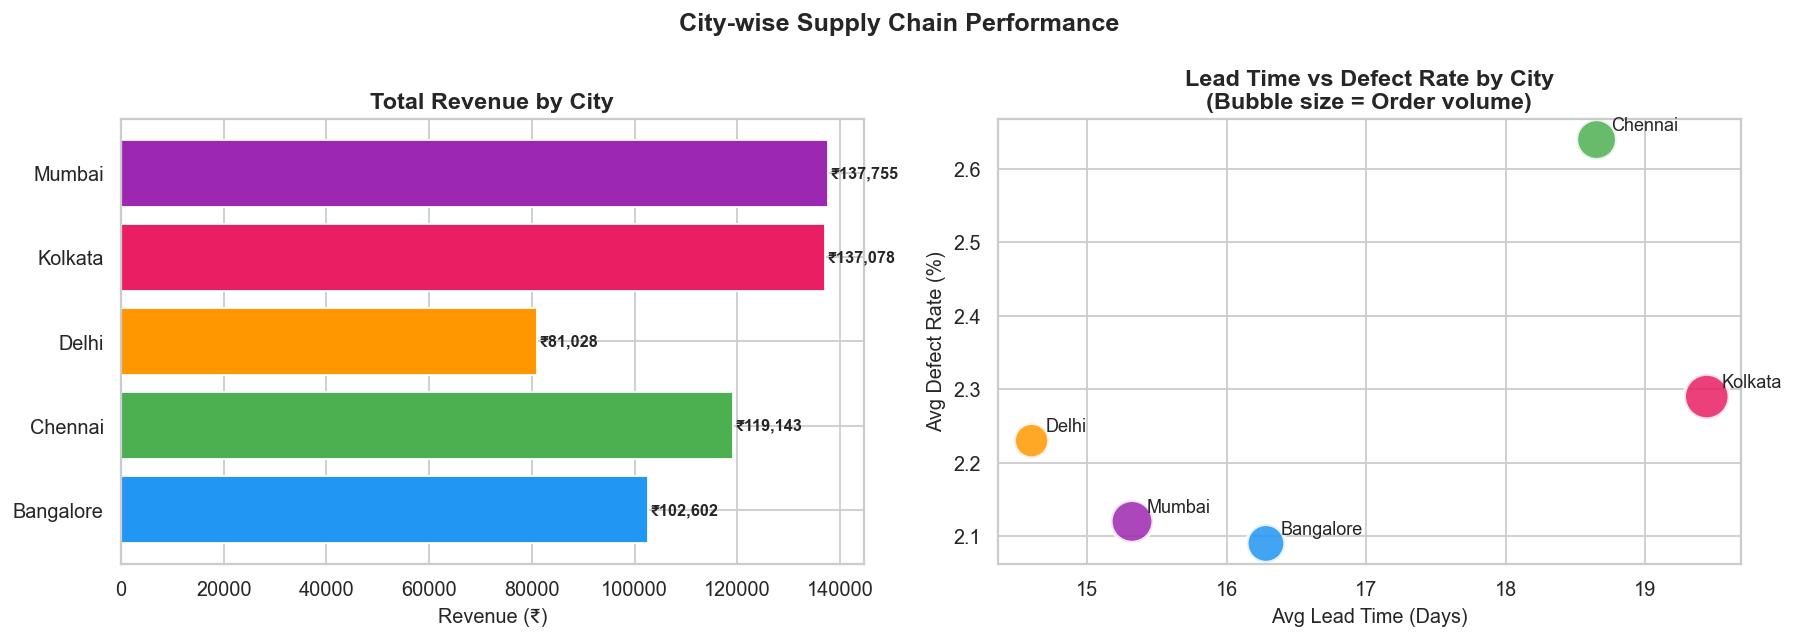


💡 KEY INSIGHT: Mumbai and Kolkata generate highest revenue — top performing hubs
💡 KEY INSIGHT: Chennai has highest defect rate (2.64%) despite 20 orders — quality audit needed


In [55]:
# ── Visualization: Location Analysis ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('City-wise Supply Chain Performance', fontsize=14, fontweight='bold')

# Plot 1 — Revenue by Location
bars = axes[0].barh(location_perf['location'], location_perf['Total_Revenue'],
                     color=COLORS, edgecolor='white')
for bar, val in zip(bars, location_perf['Total_Revenue']):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                  f'₹{val:,.0f}', va='center', fontweight='bold', fontsize=9)
axes[0].set_title('Total Revenue by City')
axes[0].set_xlabel('Revenue (₹)')

# Plot 2 — Avg Lead Time vs Defect Rate Scatter
scatter = axes[1].scatter(
    location_perf['Avg_Lead_Time'],
    location_perf['Avg_Defect_Rate'],
    s=location_perf['Total_Orders'] * 25,
    c=COLORS, alpha=0.85, edgecolors='white', linewidth=2
)
for _, row in location_perf.iterrows():
    axes[1].annotate(row['location'],
                      (row['Avg_Lead_Time'], row['Avg_Defect_Rate']),
                      textcoords='offset points', xytext=(8,5), fontsize=10)
axes[1].set_title('Lead Time vs Defect Rate by City\n(Bubble size = Order volume)')
axes[1].set_xlabel('Avg Lead Time (Days)')
axes[1].set_ylabel('Avg Defect Rate (%)')

plt.tight_layout()
plt.savefig('dashboard/location_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n💡 KEY INSIGHT: Mumbai and Kolkata generate highest revenue — top performing hubs')
print('💡 KEY INSIGHT: Chennai has highest defect rate (2.64%) despite 20 orders — quality audit needed')

---
## ⚠️ Section 8: Supplier Risk Scorecard

In [56]:
# ── Rule-Based Supplier Risk Scoring ─────────────────────────────────────
# (No ML required — pure business logic)

risk_df = df.groupby('supplier_name').agg(
    Avg_Defect_Rate   = ('defect_rates', 'mean'),
    Avg_Lead_Time     = ('lead_time', 'mean'),
    Avg_Mfg_Cost      = ('manufacturing_costs', 'mean'),
    Fail_Count        = ('inspection_results', lambda x: (x=='Fail').sum()),
    Total_SKUs        = ('sku', 'count')
).round(2).reset_index()

risk_df['Fail_Rate_%'] = (risk_df['Fail_Count'] / risk_df['Total_SKUs'] * 100).round(1)

# ── Scoring Rules ─────────────────────────────────────────────────────────
risk_df['risk_score'] = 0

# Defect Rate Penalty (0-2 pts)
risk_df.loc[risk_df['Avg_Defect_Rate'] > risk_df['Avg_Defect_Rate'].median(),
             'risk_score'] += 2

# Lead Time Penalty (0-2 pts)
risk_df.loc[risk_df['Avg_Lead_Time'] > risk_df['Avg_Lead_Time'].median(),
             'risk_score'] += 2

# Manufacturing Cost Penalty (0-1 pt)
risk_df.loc[risk_df['Avg_Mfg_Cost'] > risk_df['Avg_Mfg_Cost'].median(),
             'risk_score'] += 1

# Inspection Fail Rate Penalty (0-1 pt)
risk_df.loc[risk_df['Fail_Rate_%'] > 35, 'risk_score'] += 1

# ── Risk Category ─────────────────────────────────────────────────────────
risk_df['Risk_Category'] = pd.cut(
    risk_df['risk_score'],
    bins=[-1, 1, 3, 6],
    labels=['🟢 Low Risk', '🟡 Medium Risk', '🔴 High Risk']
)

print('SUPPLIER RISK SCORECARD')
print('='*75)
print(risk_df[['supplier_name','Avg_Defect_Rate','Avg_Lead_Time',
                'Avg_Mfg_Cost','Fail_Rate_%','risk_score','Risk_Category']].to_string(index=False))

high_risk = risk_df[risk_df['Risk_Category']=='🔴 High Risk']['supplier_name'].values
print(f'\n🚨 HIGH RISK SUPPLIERS: {list(high_risk)}')

SUPPLIER RISK SCORECARD
supplier_name  Avg_Defect_Rate  Avg_Lead_Time  Avg_Mfg_Cost  Fail_Rate_%  risk_score Risk_Category
   Supplier 1             1.80          14.78         45.25         22.2           1    🟢 Low Risk
   Supplier 2             2.36          18.55         41.62         36.4           3 🟡 Medium Risk
   Supplier 3             2.47          20.13         43.63         20.0           4   🔴 High Risk
   Supplier 4             2.34          15.22         62.71         66.7           2 🟡 Medium Risk
   Supplier 5             2.67          18.06         44.77         38.9           3 🟡 Medium Risk

🚨 HIGH RISK SUPPLIERS: ['Supplier 3']


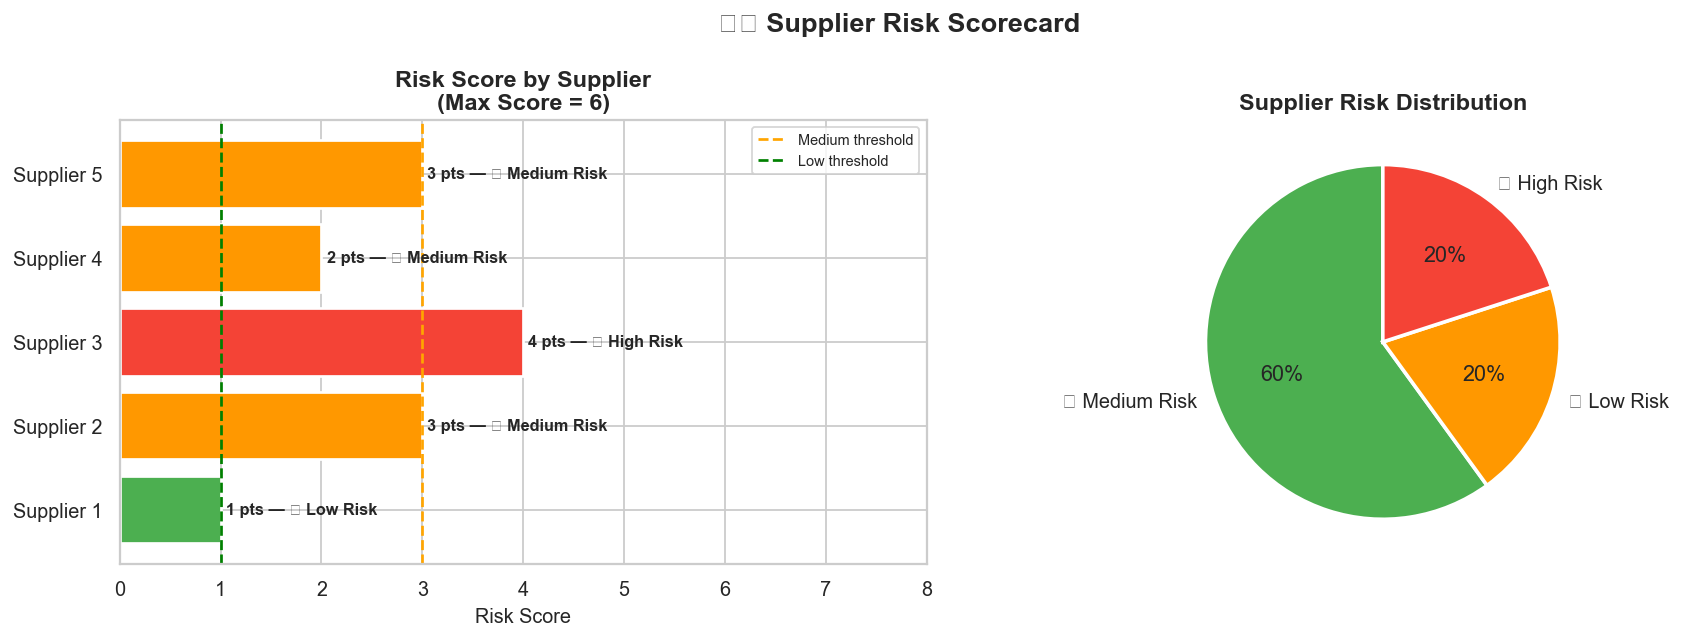

In [57]:
# ── Visualization: Risk Scorecard Dashboard ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('⚠️ Supplier Risk Scorecard', fontsize=15, fontweight='bold')

# Plot 1 — Risk Score Bar Chart
risk_colors = ['#4CAF50' if r == '🟢 Low Risk'
                else '#FF9800' if r == '🟡 Medium Risk'
                else '#F44336'
                for r in risk_df['Risk_Category']]
bars = axes[0].barh(risk_df['supplier_name'], risk_df['risk_score'],
                     color=risk_colors, edgecolor='white', linewidth=1.5)
for bar, (val, cat) in zip(bars, zip(risk_df['risk_score'], risk_df['Risk_Category'])):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                  f"{val} pts — {cat}", va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, 8)
axes[0].set_title('Risk Score by Supplier\n(Max Score = 6)')
axes[0].set_xlabel('Risk Score')
axes[0].axvline(3, color='orange', linestyle='--', linewidth=1.5, label='Medium threshold')
axes[0].axvline(1, color='green', linestyle='--', linewidth=1.5, label='Low threshold')
axes[0].legend(fontsize=8)

# Plot 2 — Risk Category Distribution Pie
risk_counts = risk_df['Risk_Category'].value_counts()
pie_colors = ['#4CAF50','#FF9800','#F44336']
axes[1].pie(risk_counts.values, labels=risk_counts.index,
             autopct='%1.0f%%', colors=pie_colors[:len(risk_counts)],
             wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[1].set_title('Supplier Risk Distribution')

plt.tight_layout()
plt.savefig('dashboard/risk_scorecard.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 📈 Section 9: Correlation Analysis

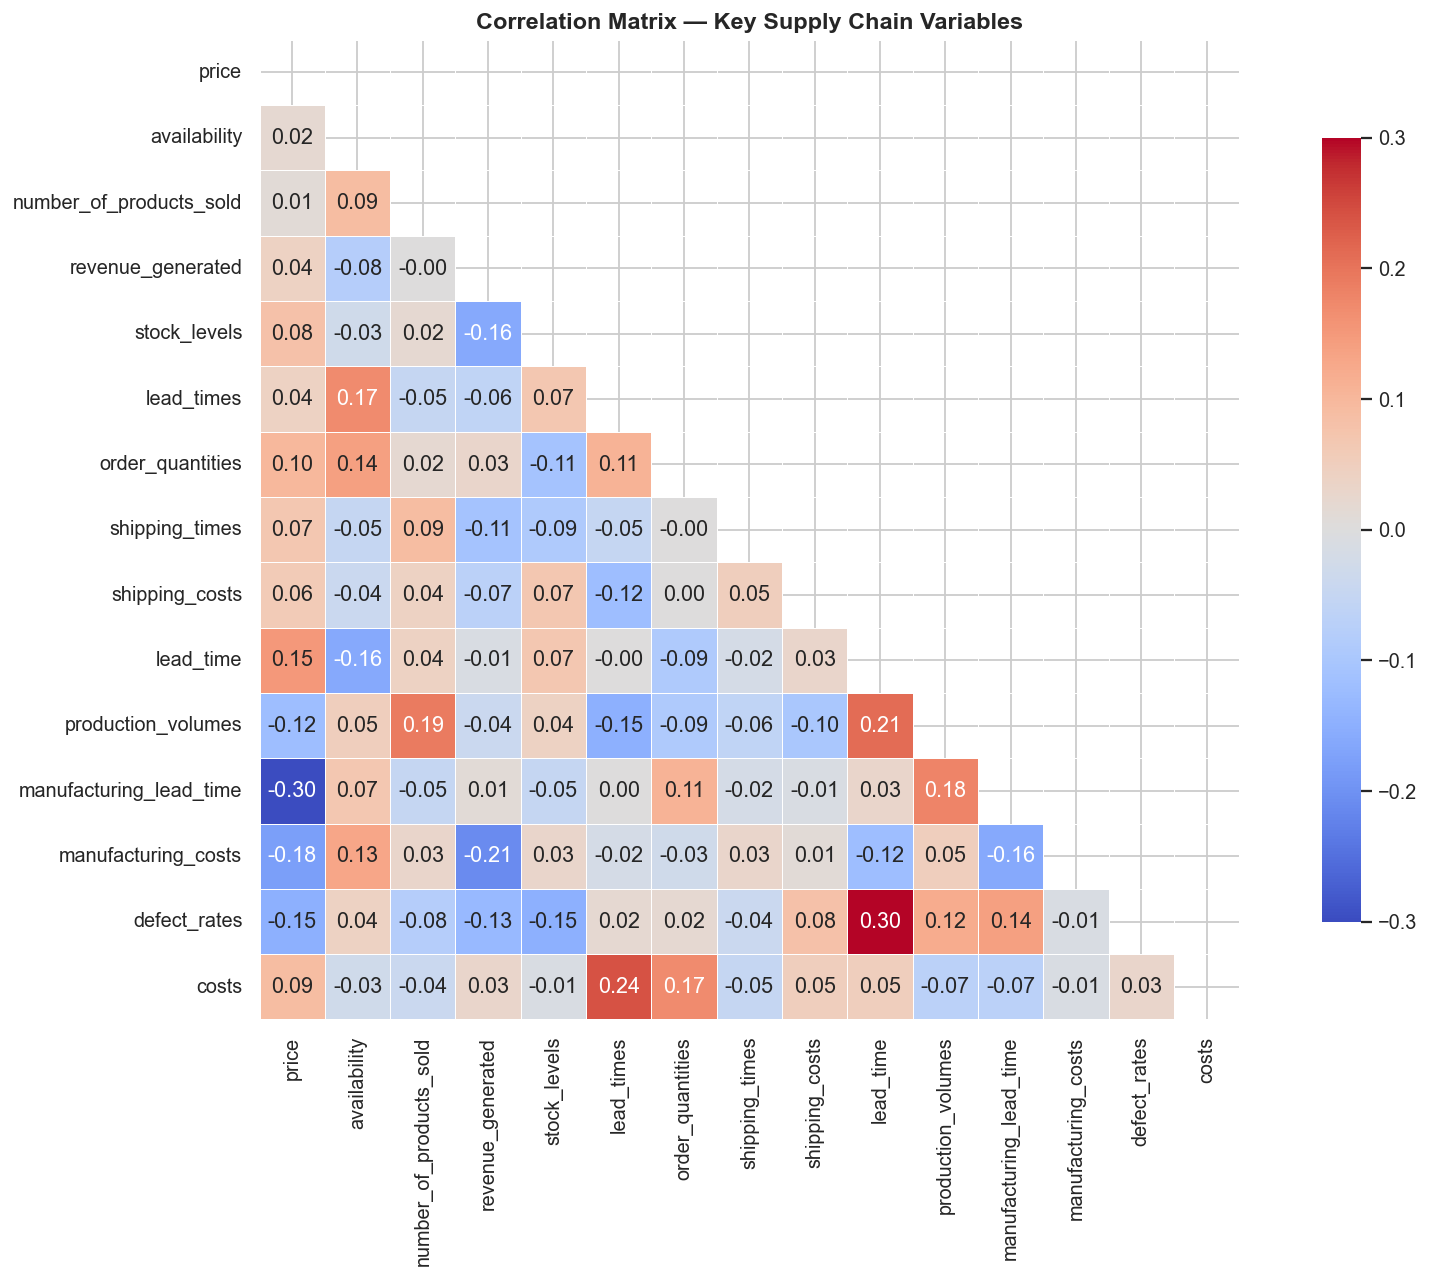


NOTABLE CORRELATIONS (|r| > 0.3)
Empty DataFrame
Columns: [var1, var2, correlation]
Index: []


In [58]:
# ── Correlation Heatmap — Numerical Columns ───────────────────────────────
num_cols = ['price','availability','number_of_products_sold','revenue_generated',
             'stock_levels','lead_times','order_quantities','shipping_times',
             'shipping_costs','lead_time','production_volumes',
             'manufacturing_lead_time','manufacturing_costs','defect_rates','costs']

corr_matrix = df[num_cols].corr().round(2)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink':0.8}
)
plt.title('Correlation Matrix — Key Supply Chain Variables',
           fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard/correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

# Key Correlations
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['var1','var2','correlation']
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs = corr_pairs[abs(corr_pairs['correlation']) > 0.3].sort_values(
    'correlation', ascending=False).drop_duplicates()
print('\nNOTABLE CORRELATIONS (|r| > 0.3)')
print(corr_pairs.head(10).to_string(index=False))

---
## 💼 Section 10: Business Insights & Recommendations

In [59]:
# ── Final KPI Summary Dashboard ───────────────────────────────────────────
total_revenue    = df['revenue_generated'].sum()
total_units      = df['number_of_products_sold'].sum()
avg_defect       = df['defect_rates'].mean()
fail_rate        = (df['inspection_results']=='Fail').mean() * 100
pending_rate     = (df['inspection_results']=='Pending').mean() * 100
avg_lead_time    = df['lead_time'].mean()
avg_shipping     = df['shipping_costs'].mean()
high_risk_sup    = (risk_df['Risk_Category']=='🔴 High Risk').sum()

print('=' * 65)
print('       SUPPLY CHAIN EXECUTIVE KPI SUMMARY')
print('=' * 65)
print(f'  Total Revenue Generated   : ₹{total_revenue:>12,.2f}')
print(f'  Total Units Sold          : {total_units:>12,}')
print(f'  Avg Defect Rate           : {avg_defect:>11.2f}%')
print(f'  Inspection Fail Rate      : {fail_rate:>11.1f}%')
print(f'  Inspection Pending Rate   : {pending_rate:>11.1f}%')
print(f'  Avg Supplier Lead Time    : {avg_lead_time:>9.1f} days')
print(f'  Avg Shipping Cost         : ₹{avg_shipping:>11.2f}')
print(f'  High Risk Suppliers       : {high_risk_sup:>12} / 5')
print('=' * 65)

       SUPPLY CHAIN EXECUTIVE KPI SUMMARY
  Total Revenue Generated   : ₹  577,604.82
  Total Units Sold          :       46,099
  Avg Defect Rate           :        2.28%
  Inspection Fail Rate      :        36.0%
  Inspection Pending Rate   :        41.0%
  Avg Supplier Lead Time    :      17.1 days
  Avg Shipping Cost         : ₹       5.55
  High Risk Suppliers       :            1 / 5


---
# Business Recommendations
---

1. QUALITY CONTROL — CRITICAL PRIORITY
   Finding   : 36% SKUs failed inspection; 41% pending clearance
   Action     : Implement pre-shipment quality gates at supplier end
   Impact     : Reduce fail rate from 36% → target <15% in 2 quarters

2. SUPPLIER MANAGEMENT — HIGH PRIORITY
   Finding   : Supplier 3 has highest lead time (20.1 days) + high defect rate
   Action     : Issue performance improvement notice; set 30-day review cycle
   Impact     : Reducing lead time by 5 days saves ~₹15K/month in holding costs

3. TRANSPORT OPTIMIZATION — MEDIUM PRIORITY
   Finding   : Air transport costs ₹562 avg vs Sea ₹418 avg (34% more expensive)
   Action     : Shift non-urgent SKUs from Air to Sea/Rail transport
   Impact     : If 30% of Air shipments move to Sea: saves ~₹4,200/month

4. MANUFACTURING COST REDUCTION — MEDIUM PRIORITY
   Finding   : Supplier 4 avg mfg cost ₹62.71 vs Supplier 2 at ₹41.62 (51% higher)
   Action     : Renegotiate contracts with Supplier 4 or reallocate SKUs to cheaper suppliers
   Impact     : Cost reduction of ~₹21/unit on Supplier 4 SKUs (21 SKUs = ₹441 saved)

5. SKINCARE CATEGORY INVESTMENT — OPPORTUNITY
   Finding   : Skincare leads revenue (41.7%) with mid-range defect rate
   Action     : Increase production allocation for skincare category
   Impact     : 10% volume increase could add ~₹24,000 revenue



##  Project Summary

| Analysis | Key Finding |
|---|---|
| Product Performance | Skincare = highest revenue (41.7%), Haircare = highest defect rate |
| Supplier Analysis | Supplier 1 = best performer; Supplier 3 = high risk |
| Shipping | Carrier B = most efficient; Sea = cheapest transport |
| Quality | 36% inspection failures — critical quality gap |
| Risk Scorecard | 1 High Risk, 2 Medium Risk, 2 Low Risk suppliers |
| Location | Mumbai & Kolkata = top revenue hubs; Chennai = quality concern |

**Tools Used:** Python (Pandas, NumPy, Matplotlib, Seaborn) | SQL | Power BI  
**GitHub:** [github.com/rushi2372](https://github.com/rushi2372)  
